In [1]:
from firedrake import IntervalMesh, FunctionSpace, TrialFunctions, \
    TestFunctions, SpatialCoordinate, Function, solve, DirichletBC, \
        Constant, grad, dx, conditional, split, project
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter
from tqdm import tqdm

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [ ]:
t0 = perf_counter()
nx = 100 #number of nodes
Lx = 25000 #length of mesh in meters
H = 200 #thickness of the bar in meters
mesh = IntervalMesh(nx, Lx)

Q1 = FunctionSpace(mesh, 'CG', 2) # η's function space
Q2 = FunctionSpace(mesh, 'CG', 2) # M's function space
Q3 = FunctionSpace(mesh, 'CG', 2) # phi_dot's function space

Q = Q1*Q2*Q3 # mixed function space for (η, M, phi_dot)

u = Function(Q) # unknowns: (η, M, phi_dot)
η, M, phi_dot = split(u)
n, m, p = TestFunctions(Q)

ρ_i = 917 # density of ice (kg/m^3)
g = 9.81 # gravitational constant (N/kg)
E = 1e9  # Young's Modulus (Pa)
μ = 1/3  # Poisson's Ratio
D = H**3*E/(12*(1 - μ**2)) * 1e12

# --- tidal parameters (added) ---
Ht_amp = 1.0            # tidal amplitude in meters
T_tide = 12.42 * 3600.0 # semidiurnal M2 period in seconds
omega = 2.0*np.pi / T_tide
# --- end tidal params ---

phi_old = Function(Q3)  # viscous curvature from previous step

day = 86400
year = 365 * day
dt = 0.1*day # timestep
viscosity = 1e12 # viscosity (Pa s)
C = viscosity*H**3 / 3  # "Flexural viscosity"

bc_η = DirichletBC(Q.sub(0), Constant(0), (1, 2)) # η = 0 on dS
bc_M = DirichletBC(Q.sub(1), Constant(0), (1, 2)) # M = 0 on dS

nt = 1000 # number of timesteps

# --- sampling setup ---
xs = np.linspace(0.0, Lx, 400)
eta_snapshots = np.zeros((nt, len(xs)))  # store η at each timestep
times = np.arange(nt) * dt               # store times if you want later
# --- end setup ---

for i in tqdm(range(nt)):
    t = i * dt
    Ht = -Ht_amp  # <-- not time-varying (meters)

    F =  (grad(m)[0]*grad(M)[0])*dx              # divergence of moment in force balance
    F += (m*ρ_i*g*η)*dx                          # force balance

    F += -(n*M)*dx                                # constitutive: -M
    F += (grad(D*n)[0]*grad(η)[0])*dx             # constitutive: curvature term
    F += n*D*(phi_old + phi_dot*dt)*dx            # constitutive: viscous curvature only

    F += p*phi_dot*dx + p*M/C*dx                  # viscous curvature evolution

    F += -(ρ_i*g*Constant(Ht)*m)*dx               # tidal forcing

    solve(F == 0, u, bcs=[bc_η, bc_M])

    # update viscous curvature
    Δphi = Function(Q3)
    Δphi.project(u[2]*dt)
    phi_old.project(phi_old + Δphi)

    deflections, moment, phi = u.subfunctions

    # save η values into numpy array
    eta_snapshots[i, :] = np.array([deflections.at((x,), tolerance=1.0e-10) for x in xs])

  0%|          | 0/1000 [00:00<?, ?it/s]/Users/bradlipovsky/Documents/simple-flex/venv-firedrake/lib/python3.13/site-packages/firedrake/function.py:556: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
/Users/bradlipovsky/Documents/simple-flex/venv-firedrake/lib/python3.13/site-packages/firedrake/function.py:556: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(
100%|██████████| 1000/1000 [00:30<00:00, 32.88it/s]


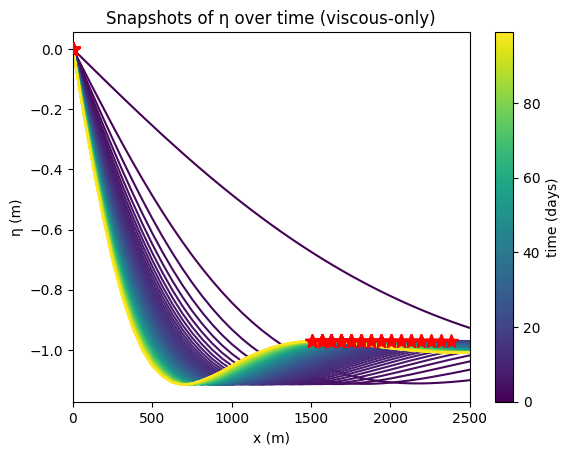

In [7]:
import numpy as np
import matplotlib as mpl
from scipy.signal import find_peaks

fig, ax = plt.subplots()
plot_every = 10
idxs = np.arange(0, nt, plot_every)
times_days = idxs * dt / day

# parula if available; otherwise viridis
cmap = mpl.colormaps['parula'] if 'parula' in mpl.colormaps else mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=times_days.min(), vmax=times_days.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# plotting range and target x
xmax_plot = Lx / 10
mask_plot = xs <= xmax_plot
x_plot = xs[mask_plot]
target_x = 1500.0
xlist = []
ylist = []

for j, i in enumerate(idxs):
    y = eta_snapshots[i, :]
    y_plot = y[mask_plot]

    # draw the curve
    ax.plot(xs, y, color=cmap(norm(times_days[j])))

    # find local peaks in the displayed range and pick the one closest to 1500 m
    peaks, _ = find_peaks(y_plot)
    if peaks.size == 0:
        choose = int(np.nanargmax(y_plot))  # fallback if no local peaks
    else:
        choose = peaks[np.argmin(np.abs(x_plot[peaks] - target_x))]

    ax.plot(x_plot[choose], y_plot[choose], marker='*', color='red', markersize=10, zorder=5)
    xlist.append(x_plot[choose])
    ylist.append(y_plot[choose])

ax.set_xlabel("x (m)")
ax.set_ylabel("η (m)")
ax.set_title("Snapshots of η over time (viscous-only)")
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("time (days)")
ax.set_xlim(0, xmax_plot)
plt.show()

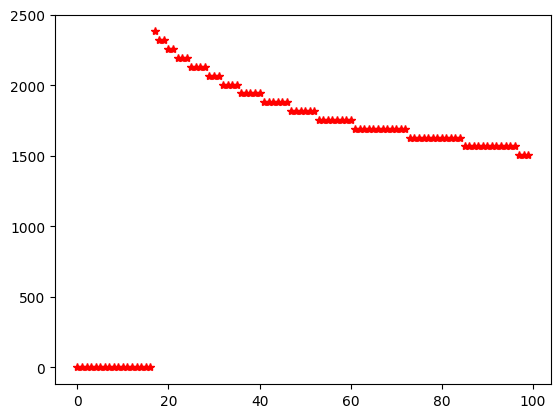

In [9]:
plt.plot(xlist,'*r')